# Activation Patching: A Guide to Uncovering Causal Circuits

## Introduction and Setup

### Abstract & Learning Objectives

Mechanistic interpretability (MI) is a subfield of AI research focused on reverse-engineering the human-understandable algorithms at play in neural Language Model (LM) computations.
Activation patching is a technique that lets us trace the LM components involved in specific behaviors.

The goal of this notebook is to explore activation patching through the lens of the similarity task: where we want the LM to discern which entity in a list has an attribute in common with a subject entity.
As we work on this task, we will also explore the theory behind activation patching, why certain decisions are made, and how activation patching helps us answer MI research questions.

#### Learning Objectives

1. Understand the core concepts behind activation patching.
2. Implement patching at different levels of granularity: residual stream, MLPs, and attention heads.
3. Apply advanced techniques like windowed and batch patching.
4. Interpret the results to form a hypothesis about the model's internal algorithm.

#### Installation & Imports

In [ ]:
%pip install -q nnsight transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from nnsight import LanguageModel

#### Model Setup

In [2]:
model_name = "meta-llama/Llama-3.3-70B-Instruct"
model = LanguageModel(model_name)

## The Selection Task & Core Concepts

### Defining the Experimental Setup

The similarity task asks the question: How does the model make a connection between two entities that share a common attribute?
For example, when asked "Which of the following entities has a profession in common with Will Smith? Keanu Reeves, Bill Clinton, Michael Jordan." the model should respond with "Keanu Reeves" since Will Smith and Keanu Reeves are both actors.

Activation patching can help us understand the LM components involved in making this connection.
We can think of a language model as being composed of a number of different structures.
Observing the architecture of the model reveals some of these components:

In [3]:
# Print the model architecture
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 8192)
    (layers): ModuleList(
      (0-79): 80 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=8192, out_features=8192, bias=False)
          (k_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (v_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (o_proj): Linear(in_features=8192, out_features=8192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (up_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (down_proj): Linear(in_features=28672, out_features=8192, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((8192,), eps=1e-05)
    (rotary_

Here we can see that Llama 70B is composed of 80 layers, each of which includes an attention layer, and an MLP layer. Each layer connects to the next through via addition to a skip-connection called the **residual stream**. We can get a sense for the relation between the residual stream, the attention layers, and the mlp layers in the diagram below:

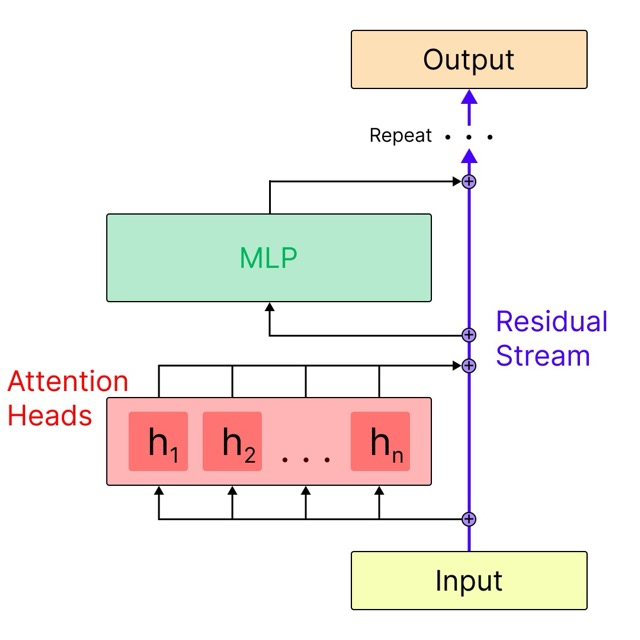

Now, our goal is to track which parts of the model are most necessary for making the correct prediction of "Keanu Reeves" in this task.
To do this, we'll first need to define two prompts: one which we'll call the **clean prompt** and another we'll call the **corrupt prompt**.

In [4]:
PROMPT_TEMPLATE = "Q: Which of the following entities has a profession in common with {}? {}.\nA:"

clean_subj = "Will Smith"
corrupt_subj = "Taylor Swift"

entity_list = ["Keanu Reeves", "Marie Curie", "Frank Sinatra"]

clean_prompt = PROMPT_TEMPLATE.format(clean_subj, (", ").join(entity_list))
print("Clean Prompt:", clean_prompt, "\n")

corrupt_prompt = PROMPT_TEMPLATE.format(corrupt_subj, (", ").join(entity_list))
print("Corrupt Prompt:", corrupt_prompt)

Clean Prompt: Q: Which of the following entities has a profession in common with Will Smith? Keanu Reeves, Marie Curie, Frank Sinatra.
A: 

Corrupt Prompt: Q: Which of the following entities has a profession in common with Taylor Swift? Keanu Reeves, Marie Curie, Frank Sinatra.
A:


Let's make sure that our two subjects are the same token length so we don't have to do any position manipulation.

In [5]:
print(model.tokenizer.encode("Taylor Swift", add_special_tokens=False))
print(model.tokenizer.encode("Will Smith", add_special_tokens=False))

[68236, 24594]
[10149, 9259]


And let's save their position in the prompt for later patching.

In [6]:
# Get token positions for the subject
clean_prompt_ids = model.tokenizer(clean_prompt).input_ids
corrupt_prompt_ids = model.tokenizer(corrupt_prompt).input_ids

subject_start = None
subject_end = None
for i, (clean_id, corrupt_id) in enumerate(zip(clean_prompt_ids, corrupt_prompt_ids)):
    if clean_id != corrupt_id and subject_start is None:
        subject_start = i
    elif clean_id == corrupt_id and subject_start is not None and subject_end is None:
        subject_end = i
        break

print(f"Subject token range: ({subject_start}, {subject_end})")

Subject token range: (14, 16)


Let's check that our model makes the expected predictions.

NOTE: Since Keanu is split up into [' K', 'eanu'] tokens, if the model predicts ' K' we consider that the start of a prediction for Keanu.

In [7]:
with model.trace(corrupt_prompt):
  corrupt_logits = model.output.logits.save()
corrupt_target_token_id = corrupt_logits.argmax(dim=-1)[:, -1]
print("Corrupt Next Token Prediction:", model.tokenizer.decode(corrupt_target_token_id))

Loading checkpoint shards:   0%|          | 0/30 [00:00<?, ?it/s]

Corrupt Next Token Prediction:  Frank


In [8]:
clean_activations = []
with model.trace(clean_prompt):
  clean_logits = model.output.logits.save()
  for l in range(model.config.num_hidden_layers):
    clean_activations.append(model.model.layers[l].output[0].save())
clean_target_token_id = clean_logits.argmax(dim=-1)[:, -1]
print("Clean Next Token Prediction:", model.tokenizer.decode(clean_target_token_id))

KeyboardInterrupt: 

Let's use activation patching to see which token and layer activations causally mediated the model's decision.

In [ ]:
from tqdm import trange

keanu_token_id = model.tokenizer(" K").input_ids[1]
frank_token_id = model.tokenizer(" Frank").input_ids[1]

clean_prompt_ids = model.tokenizer(clean_prompt).input_ids

patching_results = []
for l in trange(model.config.num_hidden_layers):
    patching_per_layer = []
    for t in range(len(clean_prompt_ids)):
        with model.trace(corrupt_prompt):
            # Patch clean -> corrupt only at position t
            model.model.layers[l].output[0][:, t] = clean_activations[l][:, t]
            patched_logits = model.output.logits.save()

        # Get the predicted token
        patched_token_id = patched_logits.argmax(dim=-1)[:, -1].item()
        patching_per_layer.append(patched_token_id)

    patching_results.append(patching_per_layer)

# Analyze results focusing on subject tokens
import numpy as np

# Convert to numpy array for easier analysis
patching_results = np.array(patching_results)

print("\nPatching effect at subject token positions:")
for l in range(model.config.num_hidden_layers):
    subject_effect = []
    for t in range(subject_start, subject_end):
        if patching_results[l, t] == clean_target_token_id:
            subject_effect.append(1)
        else:
            subject_effect.append(0)
    if sum(subject_effect) > 0:
        print(f"Layer {l}: {sum(subject_effect)}/{subject_end - subject_start} subject tokens restore clean behavior")

# Optional: Create a heatmap showing which layer/position combinations matter
import matplotlib.pyplot as plt

# Create binary matrix: 1 if patching restores clean behavior, 0 otherwise
effect_matrix = (patching_results == clean_target_token_id.item()).astype(int)

plt.figure(figsize=(12, 8))
plt.imshow(effect_matrix, aspect='auto', cmap='Blues')
plt.colorbar(label='Restores Clean Behavior')
plt.xlabel('Token Position')
plt.ylabel('Layer')
plt.title('Activation Patching Effects')

# Highlight subject token range
plt.axvline(x=subject_start-0.5, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=subject_end-0.5, color='red', linestyle='--', alpha=0.7)
plt.text(subject_start + (subject_end - subject_start)/2, -1, 'Subject Tokens', 
         ha='center', va='top', color='red')

plt.tight_layout()
plt.show()

 12%|█▎        | 10/80 [2:17:59<16:07:29, 829.27s/it]

In [75]:
model = model
tokenizer = model.tokenizer
prompt_template = PROMPT_TEMPLATE
clean_subj = clean_subj
patched_subj = corrupt_subj
common_entities = ["Keanu Reeves", "Marie Curie", "Frank Sinatra"]
metric = "logit"
ans_tokens = model.tokenizer.encode(" K")

clean_input = tokenizer(clean_prompt, return_tensors="pt", return_offsets_mapping=True)

patched_input = tokenizer(corrupt_prompt, return_tensors="pt", return_offsets_mapping=True)

subj_range = (14, 16)

# Base run
for layer_idx in range(model.config.num_hidden_layers):
    for token_idx in range(patched_input.input_ids.shape[1]):
        print(f"{token_idx=}")
        with model.trace(patched_input):
            hidden_state = model.model.layers[layer_idx].output[0][:, token_idx, :].save()
        print(f"{hidden_state=}")

token_idx=0
hidden_state=tensor([[0.0019, 0.0052, 0.0018,  ..., 0.0040, 0.0053, 0.0068]],
       grad_fn=<SliceBackward0>)
token_idx=1
hidden_state=tensor([[ 0.0043, -0.0058, -0.0091,  ..., -0.0006, -0.0058,  0.0095]],
       grad_fn=<SliceBackward0>)
token_idx=2
hidden_state=tensor([[ 0.0003,  0.0004,  0.0047,  ...,  0.0044, -0.0043, -0.0002]],
       grad_fn=<SliceBackward0>)
token_idx=3
hidden_state=tensor([[ 3.1454e-03, -2.0301e-03,  8.7671e-03,  ...,  1.0844e-02,
         -8.3692e-05,  7.6123e-03]], grad_fn=<SliceBackward0>)
token_idx=4
hidden_state=tensor([[-0.0023, -0.0008,  0.0015,  ...,  0.0012, -0.0013, -0.0053]],
       grad_fn=<SliceBackward0>)
token_idx=5
hidden_state=tensor([[ 0.0013,  0.0003, -0.0008,  ..., -0.0004, -0.0018, -0.0007]],
       grad_fn=<SliceBackward0>)
token_idx=6
hidden_state=tensor([[ 0.0016,  0.0030,  0.0043,  ...,  0.0011, -0.0084, -0.0133]],
       grad_fn=<SliceBackward0>)
token_idx=7
hidden_state=tensor([[-0.0078,  0.0036,  0.0082,  ...,  0.0137,  

KeyboardInterrupt: 

In [67]:
hidden_state.shape

torch.Size([1, 31, 8192])

In [ ]:
# APPROACH 2: Patch all subject tokens together, measure indirect effects throughout prompt
from tqdm import trange

# This measures how patching subject tokens affects ALL positions in the prompt
indirect_effects = []

for layer in trange(model.config.num_hidden_layers):
    layer_effects = []
    
    with model.trace(corrupt_prompt, remote=True):
        # Patch ALL subject entity tokens at once (clean -> corrupt)
        model.model.layers[layer].output[0][:, subject_entity_range[0]:subject_entity_range[1], :] = clean_activations[layer][:, subject_entity_range[0]:subject_entity_range[1], :]
        
        # Get logits at ALL token positions, not just the final one
        all_patched_logits = model.output.logits[0]  # Shape: [seq_len, vocab_size]
        
        # Calculate effect at each position
        for pos in range(all_patched_logits.shape[0]):
            pos_logits = all_patched_logits[pos]
            patched_clean_logit = pos_logits[clean_target_token_id].item()
            patched_corrupt_logit = pos_logits[corrupt_target_token_id].item()
            pos_diff = logit_diff(patched_clean_logit, patched_corrupt_logit)
            layer_effects.append(pos_diff.save())
    
    indirect_effects.append(layer_effects)

# indirect_effects now has shape [num_layers, seq_len] showing effects throughout the prompt


In [22]:
from tqdm import trange

# This measures how patching subject tokens affects ALL positions in the prompt
indirect_effects = []

for layer in trange(model.config.num_hidden_layers):
    with model.trace(corrupt_prompt, remote=True):
        # Patch ALL subject tokens at once
        model.model.layers[layer].output[0][:, subject_entity_range[0]:subject_entity_range[1], :] = \
            clean_activations[layer][:, subject_entity_range[0]:subject_entity_range[1], :]
        all_logits = model.output.logits[0].save()
    
    # Process outside trace context
    layer_effects = []
    for pos in range(all_logits.shape[0]):
        pos_logits = all_logits[pos]
        clean_logit = pos_logits[clean_target_token_id].item()
        corrupt_logit = pos_logits[corrupt_target_token_id].item()
        diff = logit_diff(clean_logit, corrupt_logit)
        layer_effects.append(diff)
    
    indirect_effects.append(layer_effects)

  0%|          | 0/80 [00:00<?, ?it/s]2025-07-17 06:50:20,869 8d2dfc57-b4f6-450e-9ab1-665db44259ec - RECEIVED: Your job has been received and is waiting approval.
2025-07-17 06:50:21,090 8d2dfc57-b4f6-450e-9ab1-665db44259ec - APPROVED: Your job was approved and is waiting to be run.
2025-07-17 06:50:21,469 8d2dfc57-b4f6-450e-9ab1-665db44259ec - RUNNING: Your job has started running.
2025-07-17 06:50:22,354 8d2dfc57-b4f6-450e-9ab1-665db44259ec - COMPLETED: Your job has been completed.


  1%|▏         | 1/80 [00:02<03:36,  2.73s/it]2025-07-17 06:50:23,456 8275a37f-da48-4a8a-9271-5e14b9a2eeba - RECEIVED: Your job has been received and is waiting approval.
2025-07-17 06:50:23,741 8275a37f-da48-4a8a-9271-5e14b9a2eeba - APPROVED: Your job was approved and is waiting to be run.
2025-07-17 06:50:24,110 8275a37f-da48-4a8a-9271-5e14b9a2eeba - RUNNING: Your job has started running.
2025-07-17 06:50:24,972 8275a37f-da48-4a8a-9271-5e14b9a2eeba - COMPLETED: Your job has been completed.


  2%|▎         | 2/80 [00:05<03:27,  2.66s/it]2025-07-17 06:50:26,054 6f419a48-fffc-496d-b416-2c4f897d3e80 - RECEIVED: Your job has been received and is waiting approval.
2025-07-17 06:50:26,269 6f419a48-fffc-496d-b416-2c4f897d3e80 - APPROVED: Your job was approved and is waiting to be run.
2025-07-17 06:50:26,635 6f419a48-fffc-496d-b416-2c4f897d3e80 - RUNNING: Your job has started running.
2025-07-17 06:50:27,964 6f419a48-fffc-496d-b416-2c4f897d3e80 - COMPLETED: Your job has been completed.


  4%|▍         | 3/80 [00:08<03:36,  2.82s/it]2025-07-17 06:50:29,051 aaab2c8e-e24d-4d03-90d7-33ae09a145a2 - RECEIVED: Your job has been received and is waiting approval.
2025-07-17 06:50:29,268 aaab2c8e-e24d-4d03-90d7-33ae09a145a2 - APPROVED: Your job was approved and is waiting to be run.
2025-07-17 06:50:29,644 aaab2c8e-e24d-4d03-90d7-33ae09a145a2 - RUNNING: Your job has started running.
2025-07-17 06:50:30,912 aaab2c8e-e24d-4d03-90d7-33ae09a145a2 - COMPLETED: Your job has been completed.


  5%|▌         | 4/80 [00:11<03:38,  2.87s/it]2025-07-17 06:50:32,679 4476509b-9955-4f0f-b0ad-53c71c653e6f - RECEIVED: Your job has been received and is waiting approval.
2025-07-17 06:50:32,934 4476509b-9955-4f0f-b0ad-53c71c653e6f - APPROVED: Your job was approved and is waiting to be run.
2025-07-17 06:50:33,309 4476509b-9955-4f0f-b0ad-53c71c653e6f - RUNNING: Your job has started running.
2025-07-17 06:50:34,562 4476509b-9955-4f0f-b0ad-53c71c653e6f - COMPLETED: Your job has been completed.


...

 95%|█████████▌| 76/80 [03:35<00:10,  2.57s/it]2025-07-17 06:54:00,408 ff9104cf-e05d-4926-9a94-b543a32bfa5d - RECEIVED: Your job has been received and is waiting approval.
2025-07-17 06:54:00,624 ff9104cf-e05d-4926-9a94-b543a32bfa5d - APPROVED: Your job was approved and is waiting to be run.
2025-07-17 06:54:00,995 ff9104cf-e05d-4926-9a94-b543a32bfa5d - RUNNING: Your job has started running.
2025-07-17 06:54:01,821 ff9104cf-e05d-4926-9a94-b543a32bfa5d - COMPLETED: Your job has been completed.


 96%|█████████▋| 77/80 [03:42<00:11,  3.72s/it]2025-07-17 06:54:02,704 e9aa5a23-743b-4ea0-b1e9-b4b8eb299f52 - RECEIVED: Your job has been received and is waiting approval.
2025-07-17 06:54:02,948 e9aa5a23-743b-4ea0-b1e9-b4b8eb299f52 - APPROVED: Your job was approved and is waiting to be run.
2025-07-17 06:54:03,322 e9aa5a23-743b-4ea0-b1e9-b4b8eb299f52 - RUNNING: Your job has started running.
2025-07-17 06:54:04,158 e9aa5a23-743b-4ea0-b1e9-b4b8eb299f52 - COMPLETED: Your job has been completed.


 98%|█████████▊| 78/80 [03:44<00:06,  3.31s/it]2025-07-17 06:54:05,190 6ca4677f-db95-44a7-910f-77f61d5288c6 - RECEIVED: Your job has been received and is waiting approval.
2025-07-17 06:54:05,406 6ca4677f-db95-44a7-910f-77f61d5288c6 - APPROVED: Your job was approved and is waiting to be run.
2025-07-17 06:54:05,769 6ca4677f-db95-44a7-910f-77f61d5288c6 - RUNNING: Your job has started running.
2025-07-17 06:54:06,606 6ca4677f-db95-44a7-910f-77f61d5288c6 - COMPLETED: Your job has been completed.


 99%|█████████▉| 79/80 [03:46<00:03,  3.05s/it]2025-07-17 06:54:07,493 a38ba433-3779-45ae-b514-5ad895cb39bb - RECEIVED: Your job has been received and is waiting approval.
2025-07-17 06:54:07,709 a38ba433-3779-45ae-b514-5ad895cb39bb - APPROVED: Your job was approved and is waiting to be run.
2025-07-17 06:54:08,083 a38ba433-3779-45ae-b514-5ad895cb39bb - RUNNING: Your job has started running.
2025-07-17 06:54:08,898 a38ba433-3779-45ae-b514-5ad895cb39bb - COMPLETED: Your job has been completed.


100%|██████████| 80/80 [03:49<00:00,  2.87s/it]


In [42]:
target_token_id

NameError: name 'target_token_id' is not defined